# REDES NEURONALES CONVOLUCIONALES
El dataset utilizado consiste en 60000 imágenes a color de 10 clases de animales y vehículos. El dataset en cuestión se denomina [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html). Los animales y vehículos pueden aparecer en distintas poses, en distintas posiciones de la imagen o con otros animales/ vehículos en pantalla (si bien el elemento a clasificar siempre aparece en la posición predominante).



# Carga de los datos

In [1]:
import numpy as np
import keras
import matplotlib.pyplot as plt
import pandas as pd
import keras.datasets.cifar10 as cifar10
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import datasets, layers, models, regularizers
from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix

In [2]:
# Primero, definimos los datos de entrenamiento, validación y prueba
(X, Y), (x_test, y_test) = cifar10.load_data()
(x_train, x_valid) = (X[:40000], X[40000:])
(y_train, y_valid) = (Y[:40000], Y[40000:])

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [3]:
# Normalizamos como de costumbre
# Se crea un segundo dataset normalizado y se mantiene el primero intacto
# debido a que los modelos de transfer learning necesitan la imagenes originales
# sin modificar. Para Los modelos de MLP y CNN usaremos la version normalizada,
# y para los modelos preentrenados de transfer learning, vamos a usar la version
# original.
x_train_norm = x_train / 255.
x_valid_norm = x_valid / 255.
x_test_norm = x_test / 255.

In [4]:
# Esta variable contiene un mapeo de número de clase a elemento (animal o vehículo).
MAP_ELEMENTS = {
    0: 'avion', 1: 'coche', 2: 'ave',
    3: 'gato', 4: 'ciervo', 5: 'perro', 6: 'rana',
    7: 'caballo', 8: 'barco', 9: 'camion'
}

In [5]:
# Función auxiliar para convertir las etiquetas a codificación one-hot
def convert_to_one_hot(labels, num_classes):
    return np.squeeze(np.array([to_categorical(label, num_classes=num_classes) for label in labels]))

# Convertimos las etiquetas de entrenamiento, validación y prueba
num_classes = 10
y_train_one_hot = convert_to_one_hot(y_train, num_classes)
y_valid_one_hot = convert_to_one_hot(y_valid, num_classes)
y_test_one_hot = convert_to_one_hot(y_test, num_classes)

# Verificamos las conversiones
print(y_train_one_hot.shape)
print(y_valid_one_hot.shape)
print(y_test_one_hot.shape)

(40000, 10)
(10000, 10)
(10000, 10)


#Código común a todas las secciones

In [6]:
# Definición de EarlyStopping personalizado
tf.random.set_seed(42)
class CustomEarlyStopping(tf.keras.callbacks.EarlyStopping):
    def on_epoch_end(self, epoch, logs=None):
        super().on_epoch_end(epoch, logs)
        if self.model.stop_training:
            print(f"\nEntrenamiento detenido en la época {epoch+1} por early stopping (sin mejora en val_loss).")

early_stop = CustomEarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

lrr = keras.callbacks.ReduceLROnPlateau(
                       monitor='val_accuracy',
                       factor=.01,
                       patience=3,
                       min_lr=1e-5)

In [7]:
# Función genérica para entrenar y evaluar un modelo
def train_and_evaluate(model,
                       optimizer = 'adam',
                       loss = 'categorical_crossentropy',
                       metrics = ['accuracy'],
                       epochs = 50,
                       batch_size = 128,
                       normalization = True,
                       verbose_level = 0,
                       callbacks=[early_stop]):
    """
    Compila, entrena y evalúa un modelo de Keras.

    Parámetros:
        model: instancia de tf.keras.Model aún no compilada.

        optimizer: optimizador (objeto o string) para model.compile.
        loss: función de pérdida (objeto o string).
        metrics: lista de métricas para evaluar.
        epochs: número de épocas de entrenamiento.
        batch_size: tamaño del batch.
        normalization: se usan datos de entrada normalizados (True, False).
        callbacks: lista de callbacks a utilizar durante el entrenamiento.
        verbose_level: nivel de verbosidad.

    Retorna:
        history: objeto History de Keras tras el fit.
        test_loss: pérdida en el conjunto de prueba.
        test_acc: exactitud en el conjunto de prueba.
    """
    model.summary()
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    # Usamos el dataset normalizado o no
    if normalization:
        ds_x_train = x_train_norm
        ds_x_valid = x_valid_norm
        ds_x_test = x_test_norm
    else:
        ds_x_train = x_train
        ds_x_valid = x_valid
        ds_x_test = x_test


    history = model.fit(
        ds_x_train,
        y_train_one_hot,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(ds_x_valid, y_valid_one_hot),
        callbacks=callbacks,
        verbose=verbose_level
    )

    test_loss, test_acc = model.evaluate(ds_x_test, y_test_one_hot, verbose=verbose_level)

    # Crear figura con 1 fila y 3 columnas
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ----- Gráfico 1: Texto de precisión -----
    ax0 = axes[0]
    ax0.axis('off')
    ax0.text(
        0.5, 0.5,
        f'Precisión en test: {test_acc:.4f}',
        ha='center', va='center',
        fontsize=16
    )

    # ----- Gráfico 2: Accuracy y Loss -----
    ax1 = axes[1]
    epochs = range(1, len(history.history['accuracy']) + 1)

    # Accuracy
    ax1.plot(epochs, history.history['accuracy'],     label='Accuracy entrenamiento')
    ax1.plot(epochs, history.history['val_accuracy'], label='Accuracy validación')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Accuracy')
    ax1.legend(loc='upper left')

    # Loss (eje derecho)
    ax1b = ax1.twinx()
    ax1b.plot(epochs, history.history['loss'],       linestyle='--', label='Loss entrenamiento')
    ax1b.plot(epochs, history.history['val_loss'],   linestyle=':',  label='Loss validación')
    ax1b.set_ylabel('Loss')
    ax1b.legend(loc='upper right')

    ax1.set_title('Accuracy y Loss durante el entrenamiento')
    ax1.grid(True)

    # ----- Gráfico 3: Matriz de confusión -----
    ax2 = axes[2]
    y_pred = np.argmax(model.predict(ds_x_test), axis=1)
    cm = confusion_matrix(y_test, y_pred)
    im = ax2.imshow(cm, interpolation='nearest', cmap='Blues')
    ax2.set_title('Matriz de confusión')
    ax2.set_xlabel('Etiqueta Predicha')
    ax2.set_ylabel('Etiqueta Verdadera')
    fig.colorbar(im, ax=ax2)
    ax2.grid(False)

    # Ajustar layout para que no se solapen
    plt.tight_layout()
    plt.show()

    return history, test_loss, test_acc

# A. Caso base Red Neuronal Clásica con el dataset original

El `modelo_A`, es una red neuronal de tipo **clasificador multicapa** diseñada para procesar imágenes de tamaño 32×32 con 3 canales de color (RGB) y asignar cada imagen a una de `num_classes` categorías.

**Capa de aplanamiento :** Convierte la entrada –una imagen de 32×32 píxeles con 3 canales– en un vector unidimensional de 3 072 valores (32·32·3)

**Primera capa densa \+ ReLU \+ Batch Normalization \+ Dropout:**

* **Dense(512, ReLU):** crea 512 neuronas totalmente conectadas que aprenden representaciones complejas de los datos. La función de activación ReLU introduce no linealidad.  
  * **BatchNormalization:** normaliza la salida de la capa anterior dentro de cada batch, acelerando el entrenamiento y estabilizando los gradientes.

  * **Dropout(0.2):** durante el entrenamiento, descarta aleatoriamente el 20 % de las neuronas de esta capa en cada paso, ayudando a prevenir overfitting.

**Segunda capa densa \+ ReLU \+ Dropout:** Aquí reducimos la dimensionalidad a 256 neuronas, manteniendo la no linealidad con ReLU. Aplicamos un Dropout del 10 % para seguir regularizando el modelo.

**Tercera capa densa \+ ReLU \+ Dropout:** Otra capa intermedia de 128 neuronas. El esquema de reducción progresiva (512 → 256 → 128\) permite que la red vaya concentrando la información más relevante para la clasificación.

**Capa de salida con Softmax:**  La última capa tiene tantas neuronas como clases (`num_classes`). La función de activación **softmax** convierte los valores en probabilidades, de modo que cada salida indica la probabilidad de que la imagen pertenezca a esa clase.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,740,938 (6.64 MB)

 Trainable params: 1,739,914 (6.64 MB)

 Non-trainable params: 1,024 (4.00 KB)


Entrenamiento detenido en la época 14 por early stopping (sin mejora en val_loss).
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


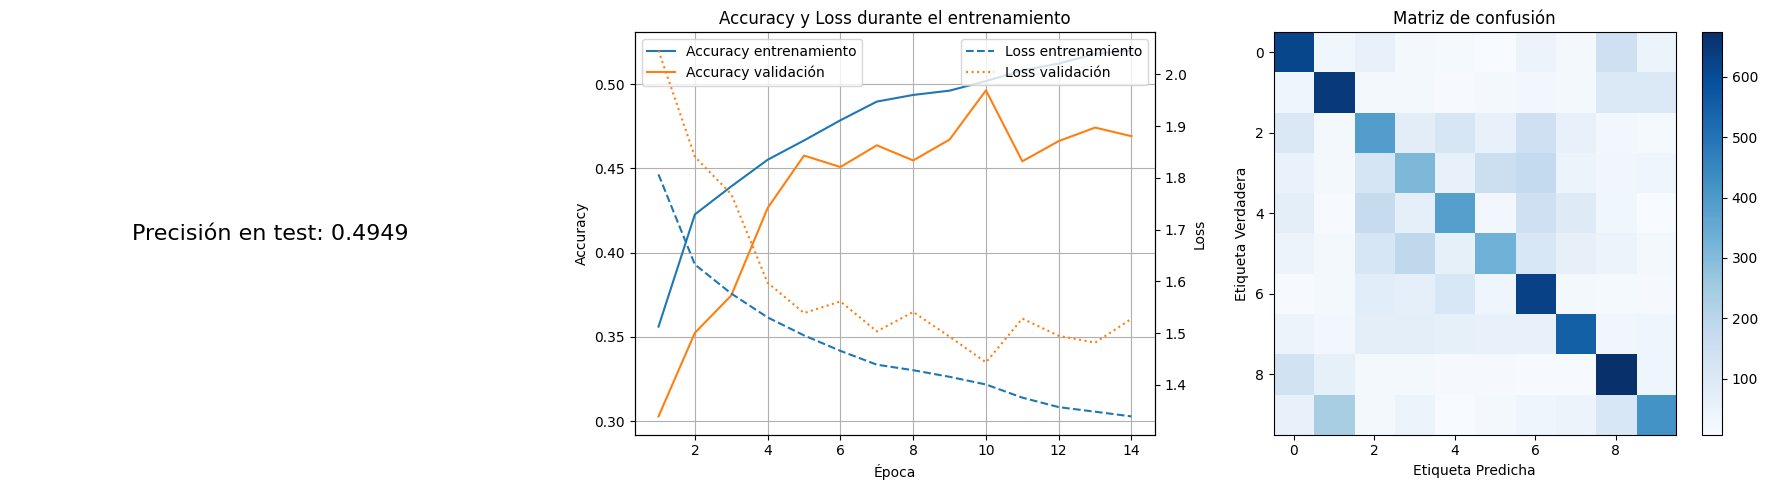

In [8]:
modelo_A = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(num_classes, activation='softmax')
])

history_A, test_lossA, test_accA = train_and_evaluate(modelo_A)

# B. Caso base Red Convolucional con el dataset original

El `modelo_B` sigue una arquitectura clásica de redes profundas diseñadas para clasificación de imágenes a color de tamaño 32×32 píxeles con tres canales (RGB).

**Capa de entrada y primera convolución:** Aquí definimos la entrada como imágenes de 32×32×3. La primera capa convolucional aplica 32 filtros de tamaño 3×3. La función de activación ReLU introduce no linealidad y evita el problema del gradiente nulo.

**Primer bloque de pooling:** Reduce cada mapa de características a la mitad en altura y anchura (de 32×32 a 16×16), conservando la característica más fuerte en cada ventana de 2×2. Esto disminuye la complejidad computacional y mejora la invarianza a pequeñas traslaciones.

**Segunda convolución y pooling:** Se duplican los filtros (ahora 64) para capturar patrones más complejos.  Nueva reducción espacial (de 16×16 a 8×8), profundizando la abstracción de las características.

**Tercera capa convolucional:** Sin pooling inmediatamente después, pero con 64 filtros exploramos aún más las relaciones espaciales en la representación de 8×8.

**Flatten Layer:** Convierte los mapas de características tridimensionales (8×8×64) en un vector unidimensional de 4096 elementos, preparándo los para las capas densas.

**Fully connected layer:** Esta capa "aprende" combinaciones de las características extraídas para formar representaciones útiles de alto nivel. Con solo 64 neuronas, se obliga a condensar la información más relevante.

**Capa de salida con Softmax:**  La última capa tiene tantas neuronas como clases (`num_classes`). La función de activación **softmax** convierte los valores en probabilidades, de modo que cada salida indica la probabilidad de que la imagen pertenezca a esa clase.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)


Entrenamiento detenido en la época 16 por early stopping (sin mejora en val_loss).
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


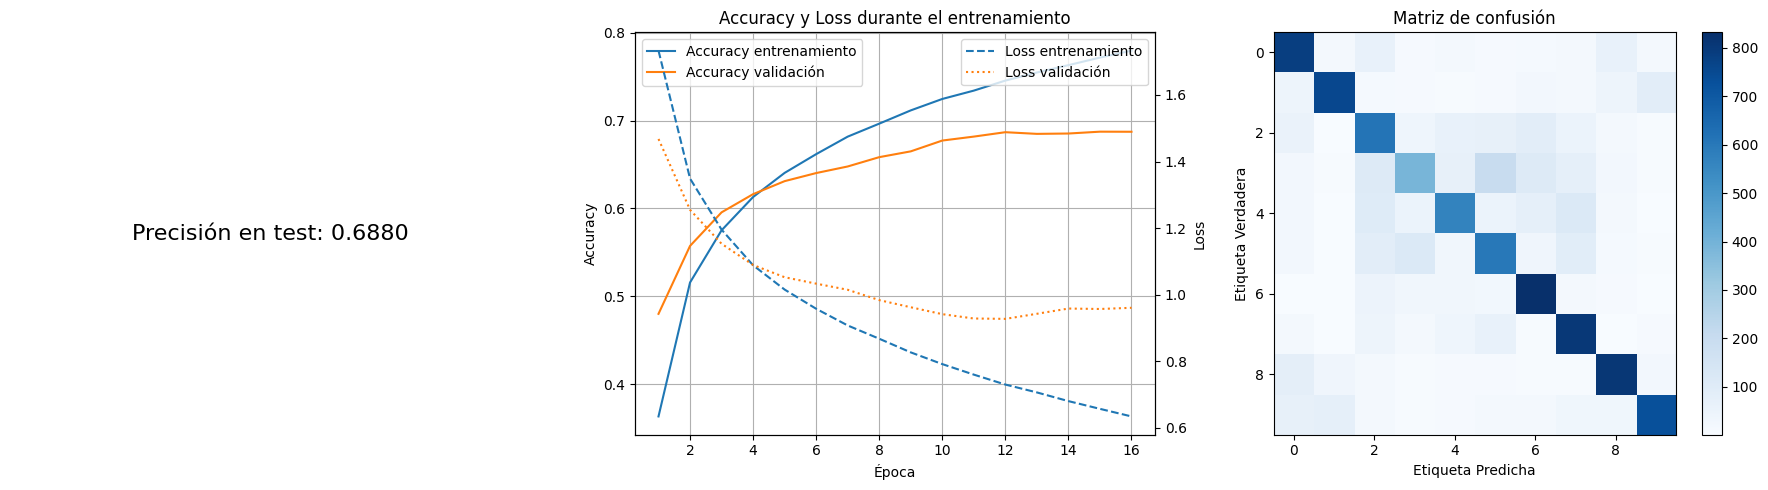

In [9]:
# Definir el modelo (CNN clásica)
modelo_B = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

history_B, test_lossB, test_accB = train_and_evaluate(modelo_B)

El `modelo_B2` es una red neuronal convolucional secuencial diseñada para clasificación de imágenes de tamaño 32×32 con 3 canales (RGB). Su arquitectura puede describirse en tres grandes bloques de extracción de características y un bloque final de clasificación:

1. **Primer bloque convolucional**
   * 64 filtros de tamaño 3×3, activación ReLU y padding "same" para mantener el tamaño espacial (32×32).
   * **BatchNormalization** para estabilizar y acelerar el entrenamiento normalizando la activación de las 64 características.
   * Otra **Conv2D** de 64 filtros 3×3 \+ ReLU \+ padding "same".
   * **MaxPooling2D** 2×2 que reduce las dimensiones a la mitad (16×16) extrayendo la característica más salient.
   * **Dropout** del 25% para evitar sobreajuste apagando aleatoriamente neuronas durante el entrenamiento.

2. **Segundo bloque convolucional**
   * Dos capas **Conv2D** idénticas, cada una con 128 filtros 3×3 \+ ReLU \+ padding "same", separadas por **BatchNormalization** tras la primera convolución para mantener estable la distribución de activaciones.
   * **MaxPooling2D** 2×2 reduce la resolución a 8×8.
   * **Dropout** al 25% para regularización adicional.

3. **Tercer bloque convolucional**
   * Una capa **Conv2D** de 256 filtros 3×3 \+ ReLU \+ padding "same" para capturar patrones más complejos, con **BatchNormalization** tras la convolución.
   * **MaxPooling2D** 2×2 reduce la resolución final a 4×4.
   * **Dropout** 25% para robustez frente al sobreajuste.

4. **Bloque denso de clasificación**
   * **Flatten** para transformar el tensor 4×4×256 en un vector de tamaño 4096.
   * **Dense** de 512 unidades con activación ReLU, que aprende combinaciones de las características extraídas.
   * **Dropout** elevado al 50%, reforzando la regularización antes de la salida.
   * **Dense** final con `num_classes` unidades y activación softmax, que produce la probabilidad de pertenencia a cada clase.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,659,914 (10.15 MB)

 Trainable params: 2,659,018 (10.14 MB)

 Non-trainable params: 896 (3.50 KB)


Entrenamiento detenido en la época 15 por early stopping (sin mejora en val_loss).
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


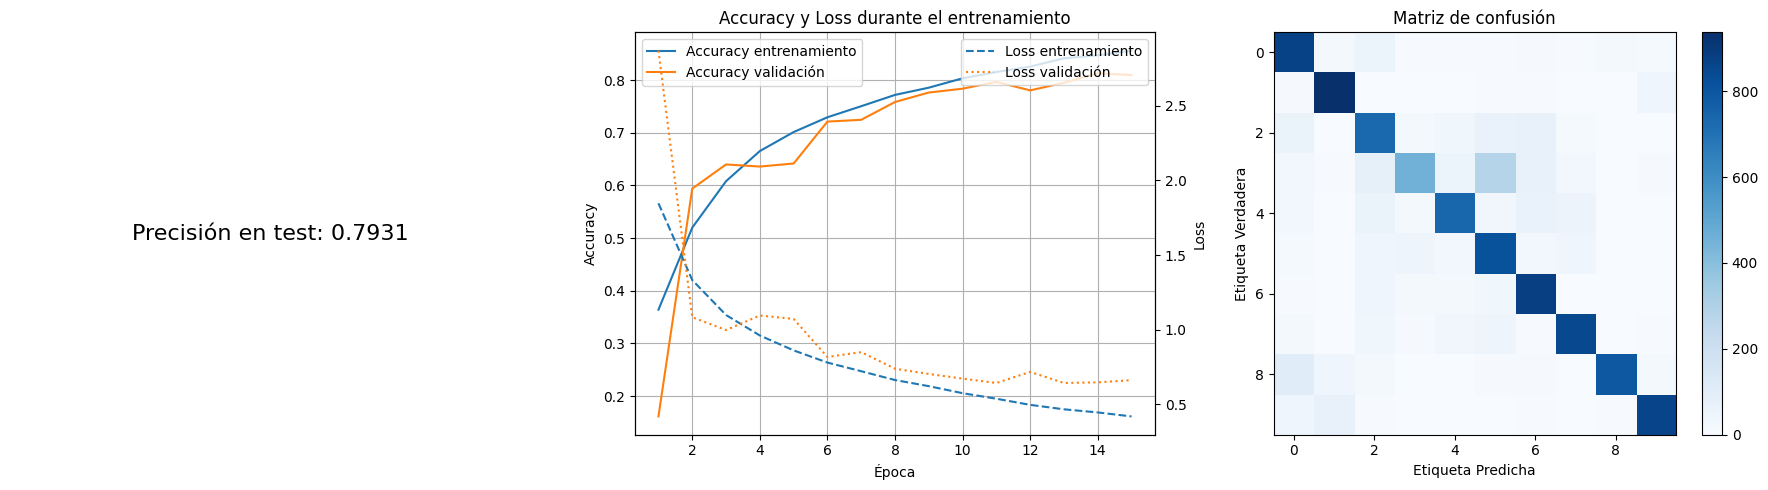

In [10]:
modelo_B2 = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

history_B2, test_lossB2, test_accB2 = train_and_evaluate(modelo_B2)

# Aplicar (Data Augmentation) al dataset

In [11]:
# Creamos una nueva capa con pequeñas variaciones aleatorias
data_augmentation = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.02),
    layers.RandomZoom(0.1),
])

# C. Red Neuronal Clásica con el dataset aumentado

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 10)             │     1,740,938 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,740,938 (6.64 MB)

 Trainable params: 1,739,914 (6.64 MB)

 Non-trainable params: 1,024 (4.00 KB)


Entrenamiento detenido en la época 7 por early stopping (sin mejora en val_loss).
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


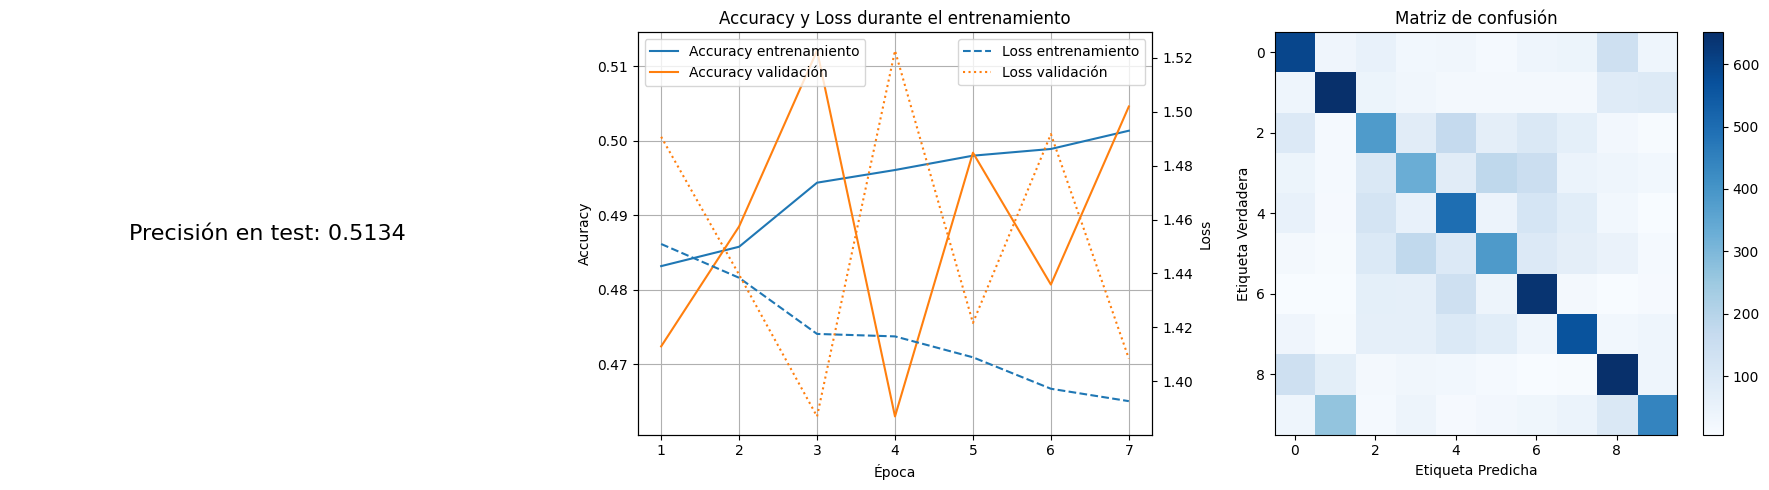

In [12]:
modelo_C = models.Sequential([
    data_augmentation,
    modelo_A
])

history_C, test_lossC, test_accC = train_and_evaluate(modelo_C)

# D. Red Convolucional con el dataset aumentado

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 10)             │       122,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)


Entrenamiento detenido en la época 16 por early stopping (sin mejora en val_loss).
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


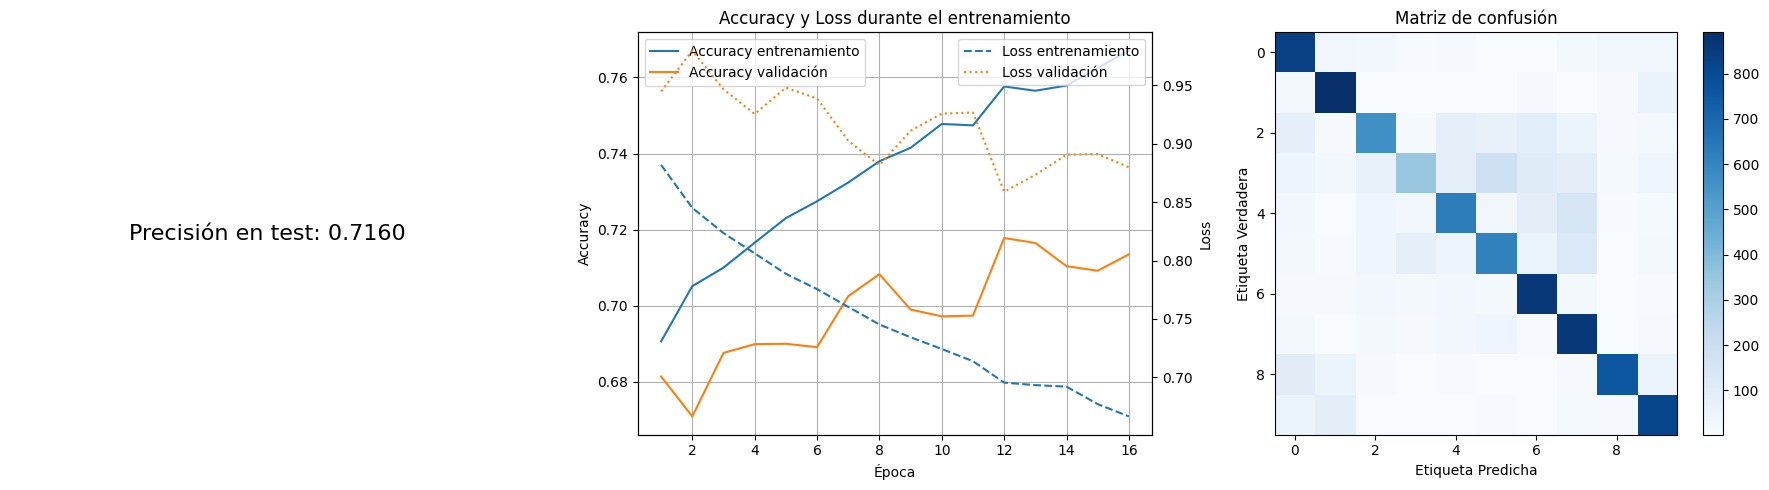

In [13]:
modelo_D = models.Sequential([
    data_augmentation,
    modelo_B
])

history_D, test_lossD, test_accD = train_and_evaluate(modelo_D)

# E. Probar diferentes configuraciones de la Red Convolucional

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 10)             │     2,659,914 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,659,914 (10.15 MB)

 Trainable params: 2,659,018 (10.14 MB)

 Non-trainable params: 896 (3.50 KB)


Entrenamiento detenido en la época 13 por early stopping (sin mejora en val_loss).
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


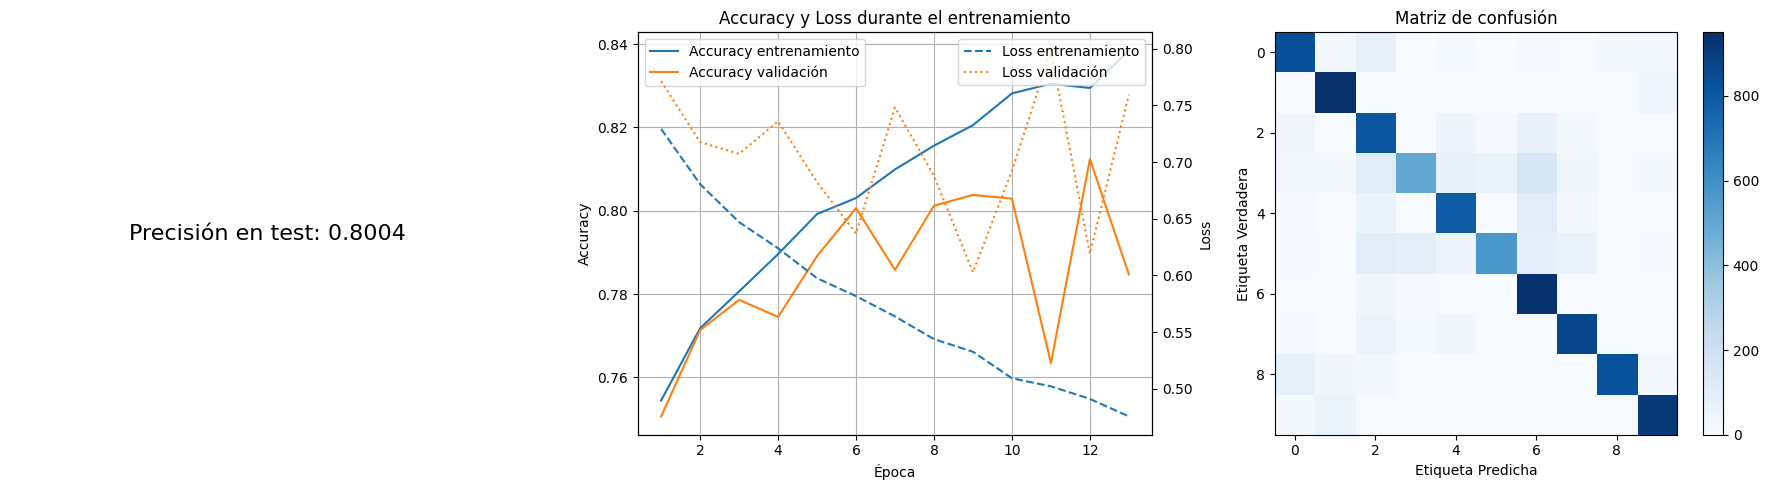

In [14]:
modelo_D2 = models.Sequential([
    data_augmentation,
    modelo_B2
])
history_D2, test_lossD2, test_accD2 = train_and_evaluate(modelo_D2)

# F. Aplicar Tranfer Learning (Opcional)

Model: "EfficientNetB0_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resize_layer (Resizing)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/50
313/313 - 83s - 266ms/step - accuracy: 0.8134 - loss: 0.6189 - val_accuracy: 0.8772 - val_loss: 0.3671
Epoch 2/50
313/313 - 51s - 164ms/step - accuracy: 0.8773 - loss: 0.3684 - val_accuracy: 0.8910 - val_loss: 0.3178
Epoch 3/50
313/313 - 43s - 136ms/step - accuracy: 0.8885 - loss: 0.3298 - val_accuracy: 0.8972 - val_loss: 0.2968
Epoch 4/50
313/313 - 43s - 138ms/step - accuracy: 0.8952 - loss: 0.3070 - val_accuracy: 0.9002 - val_loss: 0.2852
Epoch 5/50
313/313 - 79s - 252ms/step - accuracy: 0.9000 - loss: 0.2910 - val_accuracy: 0.9019 - val_loss: 0.2782
Epoch 6/50
313/313 - 44s - 140ms/step - accuracy: 0.9053 - loss: 0.2790 - val_accuracy: 0.9045 - val_loss: 0.2714
Epoch 7/50
313/313 - 81s - 260ms/step - accuracy: 0.9090 - loss: 0.2703 - val_accuracy: 0.9056 - val_loss: 0.2688
Epoch 8/50
313/313 - 82s - 261ms/step - accuracy: 0.9114 - loss: 0.2613 - val_accuracy: 0.9064 - val_loss: 0.2646
Epoch 9/50
313/313 - 41s - 130ms/step - accuracy: 0.9144 - loss: 0.2525 - val_accuracy: 

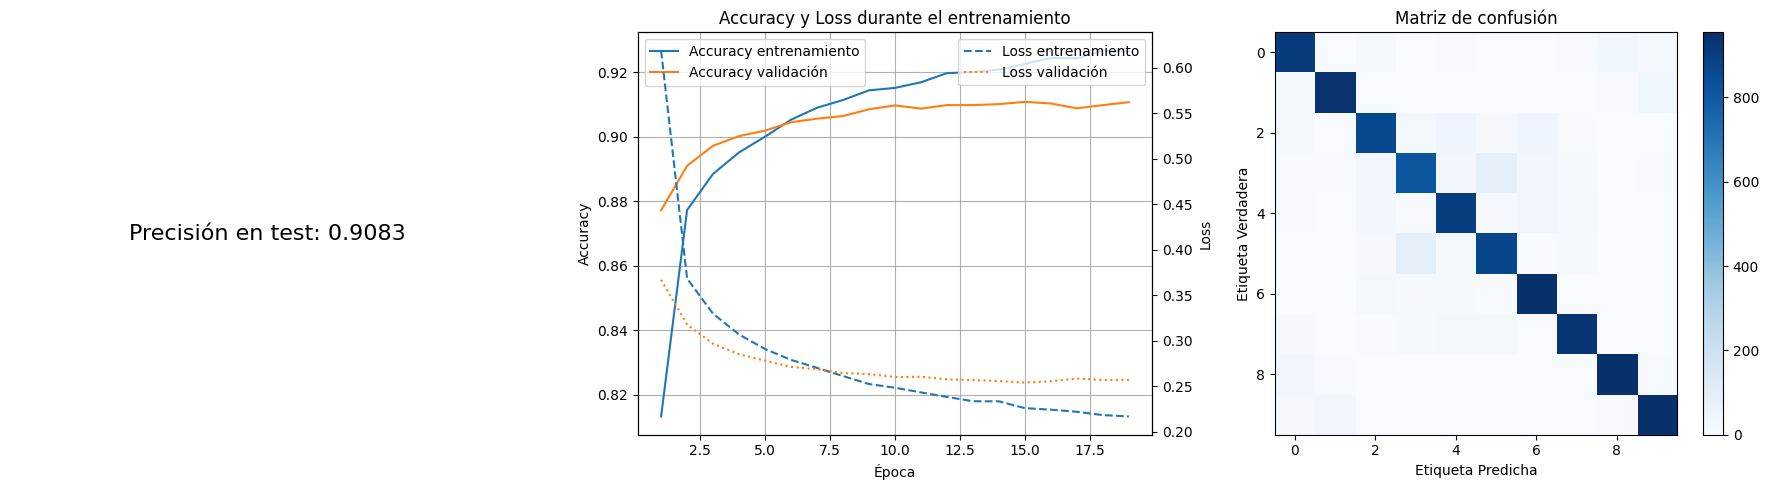

In [16]:
base3 = keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet'
)
base3.trainable = False  # congelar pesos

inputs = keras.layers.Input(shape=(32, 32, 3), name='input_layer')

# Redimensionar a 224×224 (EfficientNet espera esta resolución)
x = keras.layers.Resizing(224, 224, name='resize_layer')(inputs)

# Preprocesado específico de EfficientNet
x = keras.applications.efficientnet.preprocess_input(x)
x = base3(x, training=False)

# Pooling global
x = keras.layers.GlobalAveragePooling2D(name='global_average_pooling_layer')(x)

outputs = keras.layers.Dense(10, activation='softmax', name='output_layer')(x)

modelo_F3 = keras.Model(inputs, outputs, name='EfficientNetB0_CIFAR10')

history_F3, test_lossF3, test_accF3 = train_and_evaluate(
    modelo_F3,
    batch_size=128,
    normalization=False,
    verbose_level=2
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "ResNet50_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 32, 32)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 32, 32)    │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 32, 32)    │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 32, 32, 3) │          0 │ get_item[0][0],   │
│                     │                   │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32, 3) │          0 │ stack[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 2048)      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 10)        │     20,490 │ resnet50[0][0]    │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step


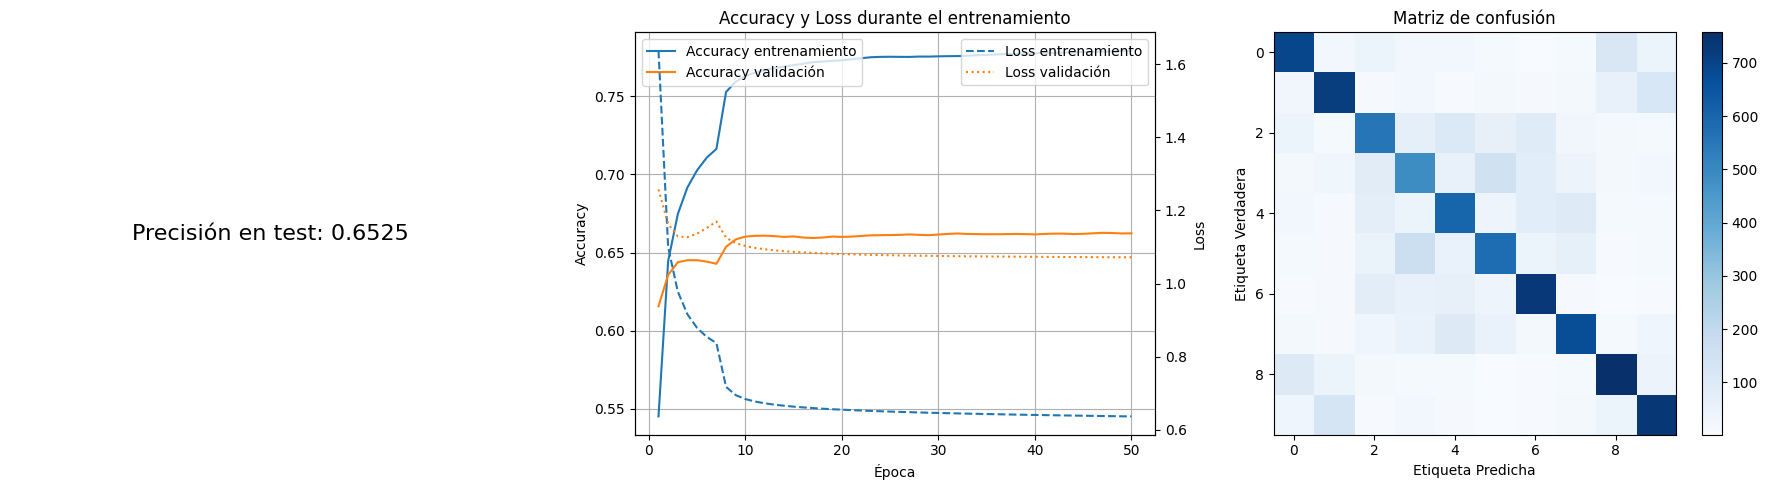

In [17]:
base4 = keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(32, 32, 3),
    pooling='avg' # aplica global average pooling internamente
)
base4.trainable = False  # congelar pesos

inputs = keras.layers.Input(shape=(32, 32, 3), name='input_layer')

# Preprocesado específico de ResNet50
x = keras.applications.resnet.preprocess_input(inputs)
x = base4(x, training=False)

outputs = keras.layers.Dense(10, activation='softmax', name='output_layer')(x)

modelo_F4 = keras.Model(inputs, outputs, name='ResNet50_CIFAR10')

history_F4, test_lossF4, test_accF4 = train_and_evaluate(
    modelo_F4,
    batch_size=128,
    normalization=False,
    callbacks=[early_stop, lrr]
)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "VGG19_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 32, 32)    │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 32, 32)    │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 32, 32)    │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 32, 32, 3) │          0 │ get_item_3[0][0], │
│                     │                   │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32, 3) │          0 │ stack_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg19 (Functional)  │ (None, 512)       │ 20,024,384 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 10)        │      5,130 │ vgg19[0][0]       │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,029,514 (76.41 MB)

 Trainable params: 5,130 (20.04 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


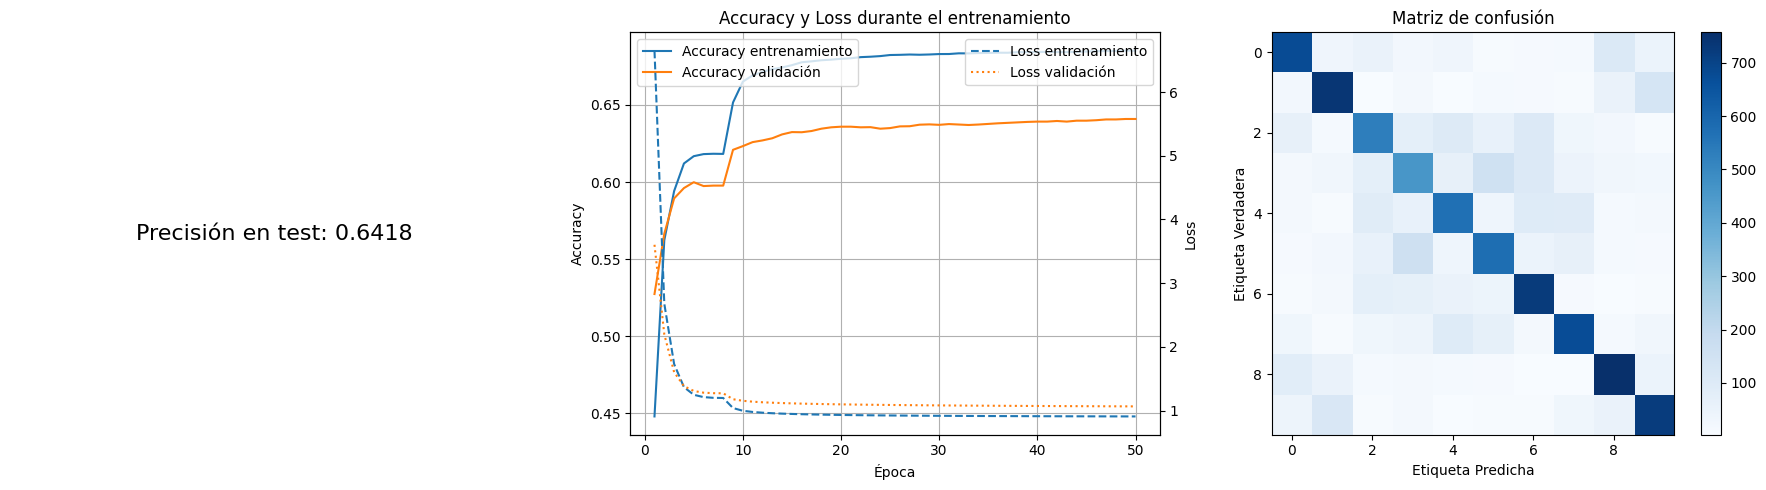

In [18]:
base5 = keras.applications.VGG19(
    include_top=False,
    weights='imagenet',
    input_shape=(32, 32, 3),
    pooling='avg' # global average pooling
)
base5.trainable = False # congelar pesos

inputs = keras.layers.Input(shape=(32, 32, 3), name='input_layer')

# Preprocesado específico de VGG19
x = keras.applications.vgg19.preprocess_input(inputs)
x = base5(x, training=False)

outputs = keras.layers.Dense(10, activation='softmax', name='output_layer')(x)

modelo_F5 = keras.Model(inputs, outputs, name='VGG19_CIFAR10')

history_F5, test_lossF5, test_accF5 = train_and_evaluate(
    modelo_F5,
    batch_size=128,
    normalization=False,
    callbacks=[early_stop, lrr]
)

| Arquitectura         | Parámetros | Profundidad | Año  | Idea principal                          |
|----------------------|:----------:|:-----------:|:----:|:----------------------------------------|
| **EfficientNet-B0**  | ~4 M     | ~20 capas   | 2019 | Compound scaling + MBConv + SE blocks   |
| **ResNet50**         | ~23.6 M      | 50 capas    | 2015 | Bloques con “skip connections”          |
| **VGG19**            | ~20 M     | 19 capas    | 2014 | Convoluciones 3×3 muy apiladas          |


# Comparativa entre las opciones (A, B, C, D, E, F)

A continuación recopilamos en una única tabla las métricas de evaluación en test de cada uno de los modelos entrenados. Los nombres de las columnas apuntan directamente a las variables que has obtenido al llamar a `train_and_evaluate`.


In [19]:
import pandas as pd

df_results = pd.DataFrame({
    'Modelo': [
        'A (MLP simple)',
        'B (CNN 1 bloque)',
        'B2 (CNN 2 bloques)',
        'C (CNN + BN + Dropout)',
        'D (CNN profundo)',
        'D2 (CNN + DataAug)',
        'EfficientNetB0 (TL)',
        'ResNet50 (TL)',
        'VGG19 (TL)'
    ],
    'Test Loss': [
        test_lossA, test_lossB, test_lossB2,
        test_lossC, test_lossD, test_lossD2,
        test_lossF3, test_lossF4, test_lossF5
    ],
    'Test Accuracy': [
        test_accA, test_accB, test_accB2,
        test_accC, test_accD, test_accD2,
        test_accF3, test_accF4, test_accF5
    ]
})

display(df_results)

,Modelo,Test Loss,Test Accuracy
0,A (MLP simple),1.425284,0.4949
1,B (CNN 1 bloque),0.921089,0.6880
2,B2 (CNN 2 bloques),0.668492,0.7931
3,C (CNN + BN + Dropout),1.372221,0.5134
4,D (CNN profundo),0.861344,0.7160
5,D2 (CNN + DataAug),0.625130,0.8004
6,EfficientNetB0 (TL),0.268218,0.9083
7,ResNet50 (TL),1.081529,0.6525
8,VGG19 (TL),1.072667,0.6418


1. **MLP vs. CNN clásico**  
    El modelo A (Multi-Layer Perceptron - MLP) es el que obtiene la peor precisión, lo cual nos dice que para CIFAR-10 es crítica la extracción de características espaciales.
    El paso al primer bloque convolucional (modelo B) ya supone una mejora notable en test accuracy.

2. **Profundidad y regularización**  
    Añadir un segundo bloque convolucional (modelo B2) y luego técnicas de *Batch Normalization* \+ *Dropout* (modelo C) incrementa de forma progresiva la robustez y la precisión, al evitar sobreajustes y estabilizar el entrenamiento.

3. **Arquitecturas profundas**  
    El modelo D (CNN profundo) supera a los anteriores, y al incorporar *data augmentation* en el modelo D2 se logra un nuevo incremento (aunque pequeño) en generalización, reflejado en la mejoría de la exactitud sobre el conjunto de test.

4. **Transfer Learning**
    A pesar que de las tres arquitecturas preentrenadas (EfficientNetB0, ResNet50 y VGG19) sólo *EfficientNetB0* alcanza la mayores precisión final, esto ilustra el poder de reutilizar representaciones de redes pre-entrenadas sobre grandes bases de datos (ImageNet), especialmente en escenarios con datos limitados como CIFAR-10.\
    \
    Respecto a los resultados por ResNet50 y VGG19, creemos que no es tanto que los modelos sean "malos", sino que su diseño y complejidad no encajan tan bien en la tarea de clasificar CIFAR-10 con recursos y datos limitados. Probablemente con mejor ajuste en los hyper parámetros e incluso un mejor pre-procesado y dataaugmentation su rendimiento pueda mejora significativamente. EfficientNetB0, en cambio, parece que tiene una ventaja clara en precisión y robustez al hacer transfer learning con el dataset CIFAR-10.\
    \
    **Nota**: En la función de entrenamiento y visualización de resultados, para las redes de transfer learning, estamos utilizando las imágenes del dataset sin normalizar (Ver comentario en el código de la sección "Carga de datos"). Las distintas eedes utilizadas, ya poseen sus propios procesos de normalización de datos de entrada.

**Conclusiones:**

* Los modelos convolucionales simples mejoran mucho la precisión del MLP.

* La profundidad, la normalización y el *dropout* mejoran aún más la generalización.

* *Data augmentation* y, sobre todo, *transfer learning* son excelentes opciones para maximizar el rendimiento en tareas de clasificación de imágenes reducidas como las del dataset CIFAR-10.